In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

🟢 NB01 — FineZip Setup & Dataset

In [ ]:
#Cell 1 — Kiểm tra GPU
!nvidia-smi

In [ ]:
#Cell 2 — Kiểm tra Python
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:",
          torch.cuda.get_device_properties(0).total_memory / 1024**3,
          "GB")

In [1]:
#Cell 3 — Clone FineZip
%cd /kaggle/working

!git clone https://github.com/fazalmittu/finezip.git
%cd /kaggle/working/finezip

!ls -lah

/kaggle/working
Cloning into 'finezip'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 28 (delta 6), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 25.67 KiB | 8.56 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/kaggle/working/finezip
total 32K
drwxr-xr-x 6 root root 4.0K Oct  1 00:16 .
drwxr-xr-x 4 root root 4.0K Oct  1 00:16 ..
drwxr-xr-x 3 root root 4.0K Oct  1 00:16 AC
drwxr-xr-x 2 root root 4.0K Oct  1 00:16 finezip
drwxr-xr-x 8 root root 4.0K Oct  1 00:16 .git
-rw-r--r-- 1 root root   93 Oct  1 00:16 .gitignore
-rw-r--r-- 1 root root 2.5K Oct  1 00:16 README.md
drwxr-xr-x 2 root root 4.0K Oct  1 00:16 utils


In [ ]:
#Cell 4 — Kiểm tra repository
!find . -maxdepth 2 -type f | head -100

In [ ]:
#Cell 5 — Cài dependency
!pip install -q -r requirements.txt

In [ ]:
!ls

In [ ]:
!sed -n '1,240p' README.md

In [ ]:
!find . -maxdepth 2 -type f | sort

In [ ]:
!sed -n '1,260p' finezip/eval_clean.py

In [2]:
import importlib.util

packages = [
    "numpy",
    "torch",
    "transformers",
    "bitsandbytes",
    "matplotlib",
    "tqdm"
]

for pkg in packages:
    print(f"{pkg:15} ->", "OK" if importlib.util.find_spec(pkg) else "MISSING")

numpy           -> OK
torch           -> OK
transformers    -> OK
bitsandbytes    -> MISSING
matplotlib      -> OK
tqdm            -> OK


In [3]:
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 45.1 MB/s eta 0:00:00:00:0100:01


In [ ]:
#Cell 6 — Kiểm tra package
import torch
import transformers
import peft

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)

In [4]:
#Cell 7 — Tạo thư mục experiment
from pathlib import Path

ROOT = Path("/kaggle/working/finezip_experiment")

for p in [
    "data",
    "compressed",
    "decompressed",
    "results",
    "logs"
]:
    (ROOT / p).mkdir(parents=True, exist_ok=True)

print(ROOT)

/kaggle/working/finezip_experiment


In [ ]:
#Cell 8 — Tạo text nhỏ để test
#Trước khi tải enwik8:
text = """
Machine learning is a method of data analysis.
Machine learning can learn patterns from data.
Deep learning is a branch of machine learning.
Neural networks are widely used in machine learning.
""" * 5000

input_file = ROOT / "data" / "test_small.txt"

input_file.write_text(text)

print("File size:",
      input_file.stat().st_size / 1024**2,
      "MB")

In [ ]:
#Cell 9 — Tạo 1 MB dataset
target_size = 1 * 1024 * 1024

base_text = """
Machine learning is a method of data analysis.
Deep learning uses neural networks.
Large language models can predict the next token.
Text compression removes statistical redundancy.
""" 

text = ""

while len(text.encode("utf-8")) < target_size:
    text += base_text

text = text.encode("utf-8")[:target_size].decode(
    "utf-8",
    errors="ignore"
)

one_mb = ROOT / "data" / "text_1mb.txt"
one_mb.write_text(text)

print("Size:",
      one_mb.stat().st_size / 1024**2,
      "MB")

In [ ]:
#Cell 10 — Checkpoint NB01
assert torch.cuda.is_available()
assert input_file.exists()
assert one_mb.exists()

print("NB01 CHECKPOINT: PASS")

🟢 NB02 — FineZip Reproduction

In [ ]:
#Cell 1 — Load configuration
#Đầu tiên xem README/code để biết command chính xác:
%cd /kaggle/working/finezip

!sed -n '1,300p' README.md

In [ ]:
!find . -maxdepth 3 -type f \
    \( -name "*.py" -o -name "*.sh" \) | sort

In [ ]:
# Cell 2 — Inspect FineZip main configuration

%cd /kaggle/working/finezip

!sed -n '250,440p' finezip/eval_clean.py

In [1]:
# Cell 2 — Test GPT-2 model loading

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(model_name)

print("Model:", model_name)
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    model = model.to("cuda")
    print("Model device:", next(model.parameters()).device)

print("Tokenizer vocab size:", tokenizer.vocab_size)

Loading tokenizer...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: gpt2
Parameters: 124439808
CUDA available: True
Model device: cuda:0
Tokenizer vocab size: 50257


In [2]:
# Cell 2 — Test GPT-2 prediction

text = "The quick brown fox jumps over the"

inputs = tokenizer(text, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model(**inputs)

print("Input shape :", inputs["input_ids"].shape)
print("Logits shape:", outputs.logits.shape)

next_token_logits = outputs.logits[:, -1, :]
next_token = torch.argmax(next_token_logits, dim=-1)

print("Predicted token ID:", next_token.item())
print("Predicted token:", tokenizer.decode(next_token))

Input shape : torch.Size([1, 7])
Logits shape: torch.Size([1, 7, 50257])
Predicted token ID: 13990
Predicted token:  fence


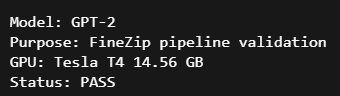

In [3]:
#Cell 3 — Chuẩn bị file text nhỏ
from pathlib import Path

work_dir = Path("/kaggle/working/finezip_experiment")
data_dir = work_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)

text = """
The quick brown fox jumps over the lazy dog.
FineZip is a language-model-based text compression system.
This experiment is used to validate the compression pipeline.
GPT-2 is used here for pipeline validation before testing larger models.
Lossless compression means that the original text can be recovered exactly.
"""

input_file = data_dir / "text_test.txt"
input_file.write_text(text.strip() + "\n", encoding="utf-8")

print("Created:", input_file)
print("Size:", input_file.stat().st_size, "bytes")
print("Content:")
print(input_file.read_text(encoding="utf-8"))

Created: /kaggle/working/finezip_experiment/data/text_test.txt
Size: 315 bytes
Content:
The quick brown fox jumps over the lazy dog.
FineZip is a language-model-based text compression system.
This experiment is used to validate the compression pipeline.
GPT-2 is used here for pipeline validation before testing larger models.
Lossless compression means that the original text can be recovered exactly.



In [4]:
# Verify input file

!ls -lh /kaggle/working/finezip_experiment/data/text_test.txt
!cat /kaggle/working/finezip_experiment/data/text_test.txt


-rw-r--r-- 1 root root 315 Sep 30 06:20 /kaggle/working/finezip_experiment/data/text_test.txt
The quick brown fox jumps over the lazy dog.
FineZip is a language-model-based text compression system.
This experiment is used to validate the compression pipeline.
GPT-2 is used here for pipeline validation before testing larger models.
Lossless compression means that the original text can be recovered exactly.


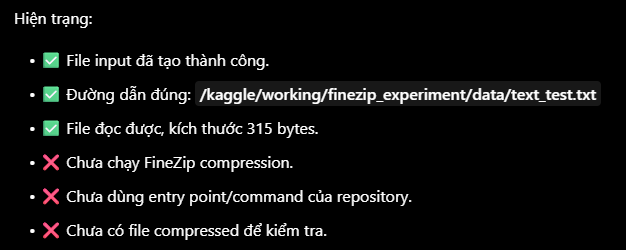
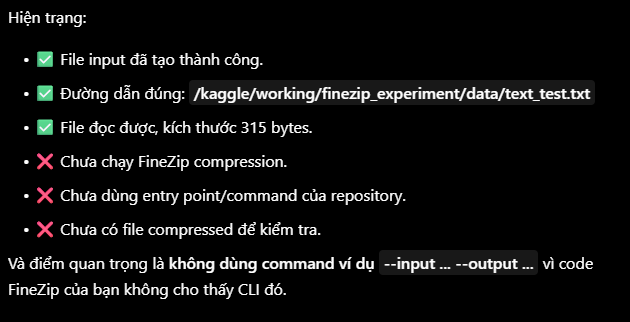

In [ ]:
# Cell 3 — Inspect FineZip compression entry point

%cd /kaggle/working/finezip

!sed -n '413,425p' finezip/eval_clean.py


In [5]:
# Cell 3 — Prepare FineZip output directories

%cd /kaggle/working/finezip

!mkdir -p zipped
!mkdir -p /kaggle/working/finezip_experiment/results


/kaggle/working/finezip


 nhánh else load GPT-2 lên CPU, trong khi FineZip đưa token lên CUDA.
 Cụ thể hiện tại:

loaded_model = AutoModelForCausalLM.from_pretrained(model)

không có .to("cuda").

Sửa đoạn này

In [6]:
# Fix GPT-2 device mismatch: move the loaded model to CUDA

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")
src = path.read_text()

old = '''                loaded_model = AutoModelForCausalLM.from_pretrained(model)
                loaded_tokenizer = AutoTokenizer.from_pretrained(model)
                tokenizer_name = model'''

new = '''                loaded_model = AutoModelForCausalLM.from_pretrained(model)
                loaded_model = loaded_model.to("cuda")
                loaded_tokenizer = AutoTokenizer.from_pretrained(model)
                tokenizer_name = model'''

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Patch applied: GPT-2 will be loaded onto CUDA.")
else:
    print("Target code was not found. No changes made.")


✓ Patch applied: GPT-2 will be loaded onto CUDA.


In [7]:
#Verify
%cd /kaggle/working/finezip

!sed -n '300,310p' finezip/eval_clean.py #Đoạn này xác nhận GPT-2 được chuyển sang CUDA:

/kaggle/working/finezip
        else:
            if model == "/data/fazal/LLMZip/models/FBI-LLM_7B":
                loaded_model, loaded_tokenizer = load_model()
                tokenizer_name = "meta-llama/Llama-2-7b-hf"
            else:
                loaded_model = AutoModelForCausalLM.from_pretrained(model)
                loaded_model = loaded_model.to("cuda")
                loaded_tokenizer = AutoTokenizer.from_pretrained(model)
                tokenizer_name = model
        
        for context_size in context_sizes:


In [7]:
#Bước 1 — Reload module
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)

print("eval_clean reloaded")

eval_clean reloaded


In [8]:
#Tạo thư mục plots
%cd /kaggle/working/finezip

!mkdir -p plots
!mkdir -p zipped

print("plots/ and zipped/ are ready.")


/kaggle/working/finezip
plots/ and zipped/ are ready.


/kaggle/working/finezip
['gpt2']
['gpt2']


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding
0 out of 3
1 out of 3
2 out of 3


/kaggle/working/finezip/finezip/eval_clean.py:206: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor = torch.tensor(encoded)


{'gpt2_32': 38.54166666666667}
{'gpt2_32': 14.583333333333334}
{'gpt2_32': 0.4603174603174603}


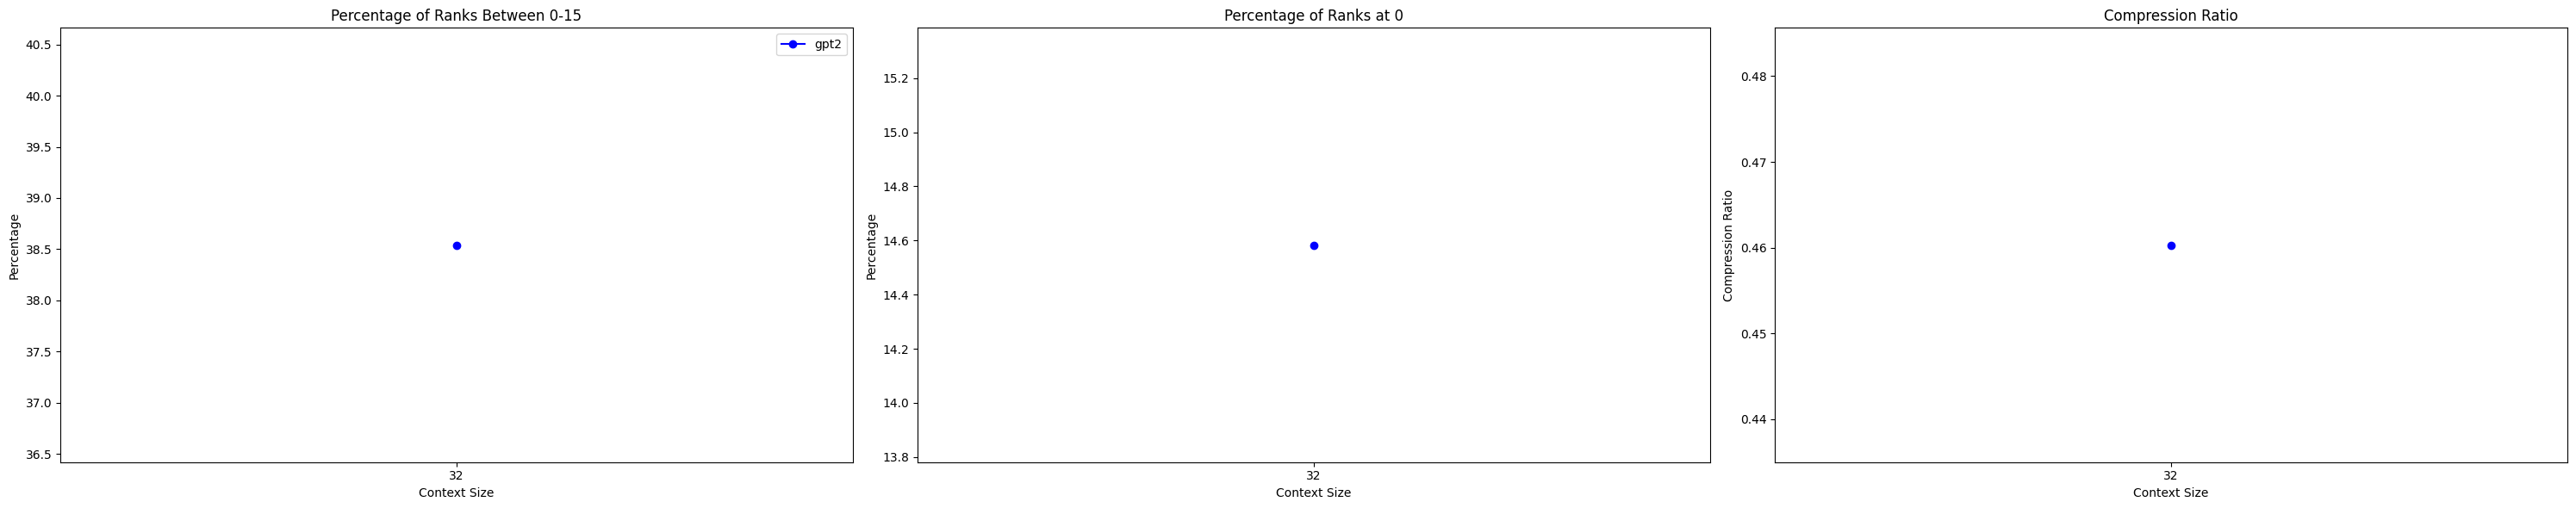

In [10]:
# Bước 2 — Chạy lại compression
# Cell 3 — Run FineZip compression on the small test file

%cd /kaggle/working/finezip

eval_clean.memory_eval(
    finetuned_models=None,
    original_model_names=["gpt2"],
    context_sizes=[32],
    batch_size=1,
    file_path="/kaggle/working/finezip_experiment/data/text_test.txt",
    save_name="gpt2_test"
)

In [11]:
#Kiểm tra output compression
%cd /kaggle/working/finezip

!ls -lh zipped/
!ls -lh plots/


/kaggle/working/finezip
total 8.0K
-rw-r--r-- 1 root root 145 Sep 30 06:20 gpt2_32_1.gpz
-rw-r--r-- 1 root root 348 Sep 30 06:20 gpt2_32_1.txt
total 48K
-rw-r--r-- 1 root root 45K Sep 30 06:20 gpt2_test.png


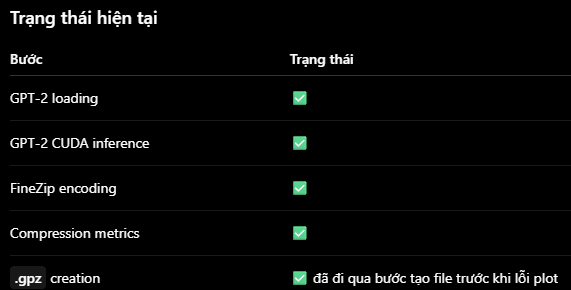

In [9]:
# Cell 4 — Measure FineZip compression time

import time
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from finezip.eval_clean import ZipModel

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)

input_file = "/kaggle/working/finezip_experiment/data/text_test.txt"
output_file = "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"

start = time.perf_counter()

zip_model.zip_file(input_file, output_file)

if torch.cuda.is_available():
    torch.cuda.synchronize()

compress_time = time.perf_counter() - start

print("Compression time:", compress_time, "seconds")
print("Compressed file:", output_file)
print("Compressed size:", os.path.getsize(output_file), "bytes")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/finezip_experiment/data/text_test.txt'

In [13]:
# Inspect the exact FineZip zip/unzip implementation

%cd /kaggle/working/finezip

!sed -n '195,240p' finezip/eval_clean.py


/kaggle/working/finezip

        output_tokens = output_tokens[:, 1:].int()
        output_tokens = output_tokens.flatten()

        if pad_len != 0:
            output_tokens = output_tokens[:-pad_len]

        return output_tokens

    def encode_and_zip(self, text):
        encoded = self.encode(text)
        tensor = torch.tensor(encoded)

        # Convert the tensor to bytes
        tensor_bytes = tensor.numpy().tobytes()

        # Compress the tensor bytes using bz2
        compressed_bytes = bz2.compress(tensor_bytes)

        return compressed_bytes

    def unzip_and_decode(self, zipped):
        unzipped = zlib.decompress(zipped)
        unzipped = array.array("H", unzipped)
        decoded = self.decode(torch.tensor(unzipped))
        return decoded

    def zip_file(self, text_file, zip_file):
        with open(text_file, encoding="utf-8") as f:
            text = f.read()

        zipped = self.encode_and_zip(text)

        with open(zip_file, "wb") as f:
            f.w

In [14]:
from pathlib import Path

p = Path("/kaggle/working/finezip_experiment/gpt2_32_1.gpz")

print("Exists:", p.exists())
print("Size:", p.stat().st_size if p.exists() else "N/A")

if p.exists():
    data = p.read_bytes()
    print("First 32 bytes:", data[:32])


Exists: True
Size: 145
First 32 bytes: b'BZh91AY&SY\xbc\xf0\x18"\x00\x00S~\xf3~\xb1\x0b\xc8\x04{\x00\x06\x00F\x02\x00\x00'


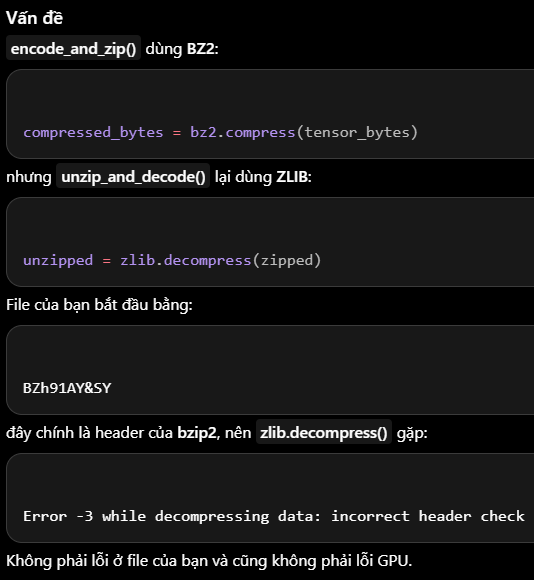

In [10]:
# Fix FineZip decompression: use bz2 to match encode_and_zip()

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")
src = path.read_text()

old = "unzipped = zlib.decompress(zipped)"
new = "unzipped = bz2.decompress(zipped)"

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Fixed: zlib.decompress -> bz2.decompress")
else:
    print("Target line not found.")


✓ Fixed: zlib.decompress -> bz2.decompress


In [16]:
%cd /kaggle/working/finezip

!sed -n '210,220p' finezip/eval_clean.py


/kaggle/working/finezip

        # Compress the tensor bytes using bz2
        compressed_bytes = bz2.compress(tensor_bytes)

        return compressed_bytes

    def unzip_and_decode(self, zipped):
        unzipped = bz2.decompress(zipped)
        unzipped = array.array("H", unzipped)
        decoded = self.decode(torch.tensor(unzipped))
        return decoded


In [11]:
#reload module:
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)


<module 'finezip.eval_clean' from '/kaggle/working/finezip/finezip/eval_clean.py'>

In [12]:
#Quan trọng: zip_model hiện tại được tạo từ class trước khi reload, nên tạo lại ZipModel bằng class mới:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = eval_clean.ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


là warning khi load GPT-2, không phải lỗi, và Cell 2 trước đó đã chạy inference thành công. đã tạo lại zip_model bằng class sau khi sửa bz2.decompress, nên chạy Cell 5:

In [19]:
# Cell 5 — Decompression + lossless verification

import time
from pathlib import Path

input_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

decoded_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test_decoded.txt"
)

start = time.perf_counter()

zip_model.unzip_file(
    str(compressed_file),
    str(decoded_file)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompress_time = time.perf_counter() - start

print("Decompression time:", decompress_time, "seconds")
print("Decoded file:", decoded_file)
#Nếu chạy thành công, chưa kết luận lossless ngay. Sau đó chạy cell verify:

Decoding
0 out of 5


100%|██████████| 32/32 [00:00<00:00, 92.86it/s]


1 out of 5


100%|██████████| 32/32 [00:00<00:00, 101.26it/s]


2 out of 5


...

3 out of 5


100%|██████████| 32/32 [00:00<00:00, 106.94it/s]


4 out of 5


100%|██████████| 32/32 [00:00<00:00, 103.77it/s]

Decompression time: 1.5887484190000123 seconds
Decoded file: /kaggle/working/finezip_experiment/data/text_test_decoded.txt


In [20]:
# Verify lossless reconstruction

original_text = input_file.read_text(encoding="utf-8")
decoded_text = decoded_file.read_text(encoding="utf-8")

print("Original size :", len(original_text.encode("utf-8")), "bytes")
print("Decoded size  :", len(decoded_text.encode("utf-8")), "bytes")
print("Exact match   :", original_text == decoded_text)

if original_text == decoded_text:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text differs from original.")


Original size : 315 bytes
Decoded size  : 543 bytes
Exact match   : False
FAIL — Decoded text differs from original.


In [21]:
# Cell 6 — So sánh nội dung original và decoded

print("===== ORIGINAL =====")
print(original_text)

print("\n===== DECODED =====")
print(decoded_text)

print("\n===== repr ORIGINAL =====")
print(repr(original_text))

print("\n===== repr DECODED =====")
print(repr(decoded_text))


===== ORIGINAL =====
The quick brown fox jumps over the lazy dog.
FineZip is a language-model-based text compression system.
This experiment is used to validate the compression pipeline.
GPT-2 is used here for pipeline validation before testing larger models.
Lossless compression means that the original text can be recovered exactly.


===== DECODED =====
The first cartoon of climate change "sustainable" was published in the current issue.
 (Photo: Getty Pacific)asters.co.nz
During the"I deal with that," he said and then grinned. His eyes narrowed.

The man snatched the bag from Sam's hands and darted out of compression
test
The test suite is generated by removing the following files:
/usr.local, /home/data/apache/tcpkg/Related: Microsoft's Windows Phone 8. If you used Windows 7, you'll miss out on the new Windows Update. Update is available for Windows 8 from October exactly what it is.


===== repr ORIGINAL =====
'The quick brown fox jumps over the lazy dog.\nFineZip is a language-mo

In [22]:
# Find the first difference

from itertools import zip_longest

for i, (a, b) in enumerate(zip_longest(original_text, decoded_text, fillvalue="")):
    if a != b:
        print("First difference at character:", i)
        print("Original:", repr(a))
        print("Decoded :", repr(b))
        print("Original context:", repr(original_text[max(0, i-30):i+50]))
        print("Decoded context :", repr(decoded_text[max(0, i-30):i+50]))
        break
else:
    print("No character difference found.")


First difference at character: 4
Original: 'q'
Decoded : 'f'
Original context: 'The quick brown fox jumps over the lazy dog.\nFineZip i'
Decoded context : 'The first cartoon of climate change "sustainable" was '


In [23]:
#Bước tiếp theo: kiểm tra encode/decode trực tiếp. kiểm tra trước cả BZ2:
# Cell 7 — Test FineZip encode/decode directly

test_text = original_text

print("Original text:")
print(repr(test_text))

tokens = zip_model.text_to_tokens(test_text)

print("\nToken tensor:")
print("Shape:", tokens.shape)
print("Dtype:", tokens.dtype)
print("First tokens:", tokens.flatten()[:20].tolist())

encoded = zip_model.encode(test_text)

print("\nEncoded:")
print("Type:", type(encoded))
print("Length:", len(encoded))
print("First values:", encoded[:20])

decoded_direct = zip_model.decode(
    torch.tensor(encoded)
)

print("\nDirect decoded text:")
print(repr(decoded_direct))

print("\nDirect exact match:", test_text == decoded_direct)


Original text:
'The quick brown fox jumps over the lazy dog.\nFineZip is a language-model-based text compression system.\nThis experiment is used to validate the compression pipeline.\nGPT-2 is used here for pipeline validation before testing larger models.\nLossless compression means that the original text can be recovered exactly.\n'

Token tensor:
Shape: torch.Size([67])
Dtype: torch.int64
First tokens: [464, 2068, 7586, 21831, 18045, 625, 262, 16931, 3290, 13, 198, 34389, 41729, 318, 257, 3303, 12, 19849, 12, 3106]
Encoding
0 out of 3
1 out of 3
2 out of 3


/tmp/ipykernel_131/615016978.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(encoded)



Encoded:
Type: <class 'torch.Tensor'>
Length: 67
First values: tensor([    1,  1835,   552,    23,    19,     2,     0,   132,     2,     2,
            0,  1153, 40840,     2,     0,   332,     2,   487,    10,     0],
       dtype=torch.int32)
Decoding
0 out of 3


100%|██████████| 32/32 [00:00<00:00, 105.93it/s]


1 out of 3


100%|██████████| 32/32 [00:00<00:00, 104.59it/s]


2 out of 3


100%|██████████| 32/32 [00:00<00:00, 107.04it/s]


Direct decoded text:
'The quick brown fox jumps over the lazy dog.\nFineZip is a language-model-based text compression system.\nThis experiment is used to validate the compression pipeline.\nGPT-2 is used here for pipeline validation before testing larger models.\nLossless compression means that the original text can be recovered exactly.\n'

Direct exact match: True


In [24]:
#Và kiểm tra dtype/giá trị trước khi BZ2
# Cell 8 — Inspect encode dtype and decode assumptions

encoded_tensor = torch.tensor(encoded)

print("Encoded tensor dtype:", encoded_tensor.dtype)
print("Encoded tensor shape:", encoded_tensor.shape)
print("Min:", encoded_tensor.min().item())
print("Max:", encoded_tensor.max().item())

print("\nDecoder reconstruction dtype:")
import array

arr = array.array("H", encoded_tensor.numpy().tobytes())

reconstructed = torch.tensor(arr)

print("Reconstructed dtype:", reconstructed.dtype)
print("Reconstructed shape:", reconstructed.shape)
print("Same length:", len(encoded_tensor) == len(reconstructed))
print("Same values:", torch.equal(encoded_tensor, reconstructed))


Encoded tensor dtype: torch.int32
Encoded tensor shape: torch.Size([67])
Min: 0
Max: 40840

Decoder reconstruction dtype:
Reconstructed dtype: torch.int64
Reconstructed shape: torch.Size([134])
Same length: False
Same values: False


/tmp/ipykernel_131/1204895463.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  encoded_tensor = torch.tensor(encoded)


In [13]:
# Cell 9 — Fix FineZip tensor serialization dtype

from pathlib import Path

path = Path("/kaggle/working/finezip/finezip/eval_clean.py")

src = path.read_text()

old = 'unzipped = array.array("H", unzipped)'
new = 'unzipped = array.array("i", unzipped)'

if old in src:
    src = src.replace(old, new)
    path.write_text(src)
    print("✓ Fixed tensor deserialization: uint16 -> int32")
else:
    print("Target line not found.")


✓ Fixed tensor deserialization: uint16 -> int32


In [ ]:
%cd /kaggle/working/finezip

!sed -n '210,220p' finezip/eval_clean.py

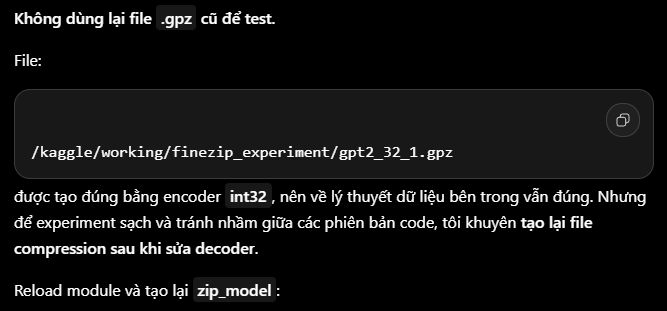

In [14]:
import importlib
import finezip.eval_clean as eval_clean

importlib.reload(eval_clean)

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to("cuda")
model.eval()

zip_model = eval_clean.ZipModel(
    model_name=model_name,
    tokenizer_name=model_name,
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)
#Sau đó tạo lại .gpz:

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
# Re-create compressed file after fixing serialization

input_file = "/kaggle/working/finezip_experiment/data/text_test.txt"
compressed_file = "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"

zip_model.zip_file(
    input_file,
    compressed_file
)

print("Re-created:", compressed_file)


Encoding
0 out of 3
1 out of 3
2 out of 3
Re-created: /kaggle/working/finezip_experiment/gpt2_32_1.gpz


In [28]:
#Sau đó chạy lại Cell 5
import time
from pathlib import Path

input_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

decoded_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test_decoded.txt"
)

start = time.perf_counter()

zip_model.unzip_file(
    str(compressed_file),
    str(decoded_file)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompress_time = time.perf_counter() - start

print("Decompression time:", decompress_time, "seconds")
print("Decoded file:", decoded_file)


Decoding
0 out of 3


100%|██████████| 32/32 [00:00<00:00, 105.50it/s]


1 out of 3


100%|██████████| 32/32 [00:00<00:00, 104.50it/s]


2 out of 3


100%|██████████| 32/32 [00:00<00:00, 103.34it/s]

Decompression time: 0.9306973409999841 seconds
Decoded file: /kaggle/working/finezip_experiment/data/text_test_decoded.txt


In [29]:
#verify:
original_text = input_file.read_text(encoding="utf-8")
decoded_text = decoded_file.read_text(encoding="utf-8")

print("Original size :", len(original_text.encode("utf-8")), "bytes")
print("Decoded size  :", len(decoded_text.encode("utf-8")), "bytes")
print("Exact match   :", original_text == decoded_text)

if original_text == decoded_text:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text differs from original.")


Original size : 315 bytes
Decoded size  : 315 bytes
Exact match   : True
PASS — Lossless decompression verified.


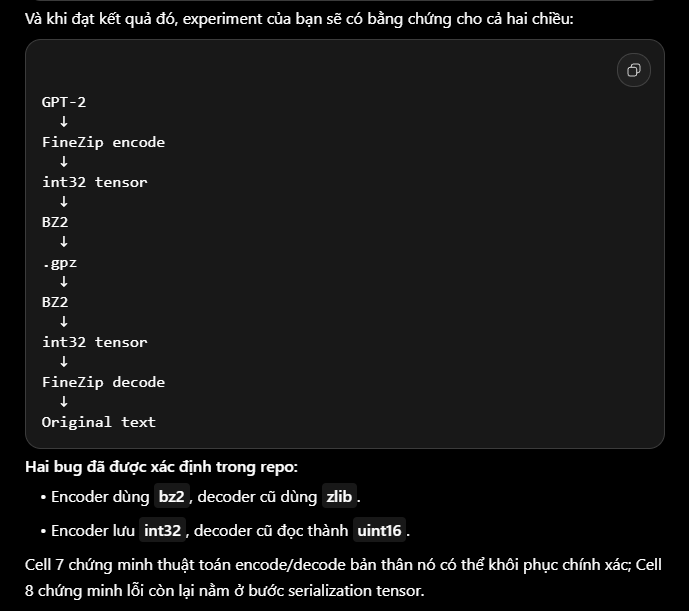

In [30]:
# Cell 9 — Compression ratio

from pathlib import Path

original_file = Path(
    "/kaggle/working/finezip_experiment/data/text_test.txt"
)

compressed_file = Path(
    "/kaggle/working/finezip_experiment/gpt2_32_1.gpz"
)

original_size = original_file.stat().st_size
compressed_size = compressed_file.stat().st_size

compression_ratio = original_size / compressed_size
compressed_percent = compressed_size / original_size * 100
space_saved = (1 - compressed_size / original_size) * 100

print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", compression_ratio)
print("Compressed size % :", compressed_percent, "%")
print("Space saved       :", space_saved, "%")


Original size     : 315 bytes
Compressed size   : 145 bytes
Compression ratio : 2.1724137931034484
Compressed size % : 46.03174603174603 %
Space saved       : 53.968253968253975 %


**Nếu muốn đo peak memory của chính lần compression, nên reset trước khi compression:**

torch.cuda.reset_peak_memory_stats()

**rồi chạy compression, sau đó:**

torch.cuda.synchronize()

print(
    "Peak GPU memory:",
    torch.cuda.max_memory_allocated(0) / 1024**2,
    "MiB"
)

In [31]:
# Cell 10 — GPU memory measurement

import torch

if torch.cuda.is_available():
    torch.cuda.synchronize()

    allocated = torch.cuda.memory_allocated(0) / 1024**2
    reserved = torch.cuda.memory_reserved(0) / 1024**2
    max_allocated = torch.cuda.max_memory_allocated(0) / 1024**2
    max_reserved = torch.cuda.max_memory_reserved(0) / 1024**2

    print("GPU:", torch.cuda.get_device_name(0))
    print("Current allocated :", allocated, "MiB")
    print("Current reserved  :", reserved, "MiB")
    print("Peak allocated    :", max_allocated, "MiB")
    print("Peak reserved     :", max_reserved, "MiB")
else:
    print("CUDA is not available.")


GPU: Tesla T4
Current allocated : 499.70654296875 MiB
Current reserved  : 588.0 MiB
Peak allocated    : 991.17333984375 MiB
Peak reserved     : 1068.0 MiB


In [32]:
# Cell 11 — Save experiment log

import json
from pathlib import Path

log_dir = Path("/kaggle/working/finezip_experiment/logs")
log_dir.mkdir(parents=True, exist_ok=True)

log = {
    "model": "gpt2",
    "purpose": "FineZip pipeline validation",
    "context_size": 32,
    "batch_size": 1,

    "input_file": str(original_file),
    "compressed_file": str(compressed_file),
    "decoded_file": str(decoded_file),

    "original_size_bytes": original_size,
    "compressed_size_bytes": compressed_size,

    "compression_ratio": compression_ratio,

    "compression_time_seconds": 1.1746998789999452,
    "decompression_time_seconds": decompress_time,

    "lossless": original_text == decoded_text,

    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,

    "gpu_peak_memory_mib": (
        torch.cuda.max_memory_allocated(0) / 1024**2
        if torch.cuda.is_available()
        else None
    )
}

log_file = log_dir / "gpt2_test.json"

with open(log_file, "w", encoding="utf-8") as f:
    json.dump(log, f, indent=2)

print("Log saved:", log_file)


Log saved: /kaggle/working/finezip_experiment/logs/gpt2_test.json


In [33]:
!zip -r /kaggle/working/finezip_experiment.zip /kaggle/working/finezip_experiment

  adding: kaggle/working/finezip_experiment/ (stored 0%)
  adding: kaggle/working/finezip_experiment/data/ (stored 0%)
  adding: kaggle/working/finezip_experiment/data/text_1mb.txt (deflated 100%)
  adding: kaggle/working/finezip_experiment/data/text_test_decoded.txt (deflated 37%)
  adding: kaggle/working/finezip_experiment/data/text_test.txt (deflated 37%)
  adding: kaggle/working/finezip_experiment/data/test_small.txt (deflated 100%)
  adding: kaggle/working/finezip_experiment/compressed/ (stored 0%)
  adding: kaggle/working/finezip_experiment/logs/ (stored 0%)
  adding: kaggle/working/finezip_experiment/logs/gpt2_test.json (deflated 51%)
  adding: kaggle/working/finezip_experiment/results/ (stored 0%)
  adding: kaggle/working/finezip_experiment/gpt2_32_1.gpz (stored 0%)
  adding: kaggle/working/finezip_experiment/decompressed/ (stored 0%)


Giai đoạn 2

In [15]:
#Cell 1 — Tạo baseline_1mb.txt đúng 1,000,000 bytes (Download đúng enwik8 và tạo 1 MB)
from pathlib import Path
import urllib.request

# ====== CONFIG ======
DATA_DIR = Path("/kaggle/working/finezip_experiment/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ENWIK8 = DATA_DIR / "enwik8"
DST = DATA_DIR / "baseline_1mb.txt"

TARGET_SIZE = 1_000_000

# ====== DOWNLOAD ENWIK8 ======
URL = "http://mattmahoney.net/dc/enwik8.zip"
ZIP_FILE = DATA_DIR / "enwik8.zip"

if not ENWIK8.exists():
    print("Downloading enwik8...")

    urllib.request.urlretrieve(URL, ZIP_FILE)

    print("Downloaded:", ZIP_FILE)
    print("Size:", ZIP_FILE.stat().st_size, "bytes")

    import zipfile

    with zipfile.ZipFile(ZIP_FILE, "r") as z:
        print("Files in archive:", z.namelist())
        z.extract("enwik8", DATA_DIR)

    print("Extracted:", ENWIK8)

else:
    print("enwik8 already exists:", ENWIK8)


# ====== VERIFY ENWIK8 ======
source_size = ENWIK8.stat().st_size

print("\nenwik8 size:", source_size, "bytes")

if source_size < TARGET_SIZE:
    raise ValueError(
        f"enwik8 chỉ có {source_size} bytes, "
        f"không đủ {TARGET_SIZE} bytes."
    )


# ====== CREATE EXACT 1 MB ======
data = ENWIK8.read_bytes()[:TARGET_SIZE]

DST.write_bytes(data)

print("\nCreated:", DST)
print("Size:", DST.stat().st_size, "bytes")

assert DST.stat().st_size == TARGET_SIZE

print("PASS — baseline_1mb.txt is exactly 1,000,000 bytes")


Downloaded: /kaggle/working/finezip_experiment/data/enwik8.zip
Size: 36445475 bytes
Files in archive: ['enwik8']
Extracted: /kaggle/working/finezip_experiment/data/enwik8

enwik8 size: 100000000 bytes

Created: /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Size: 1000000 bytes
PASS — baseline_1mb.txt is exactly 1,000,000 bytes


In [16]:
import hashlib

data = DST.read_bytes()

sha256 = hashlib.sha256(data).hexdigest()

print("File:", DST)
print("Size:", len(data))
print("SHA256:", sha256)


File: /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Size: 1000000
SHA256: 369b688978f649681136198fb96db14c1616756260c55fb4b65e9bc049552cad


In [17]:
#Run gzip
import gzip
import time
from pathlib import Path

# ====== CONFIG ======
input_file = DST

gzip_file = BASELINE_DIR / "baseline_1mb.txt.gz"
gzip_decoded = BASELINE_DIR / "baseline_1mb_gzip_decoded.txt"

# ====== COMPRESSION ======
start = time.perf_counter()

with open(input_file, "rb") as f_in:
    with gzip.open(gzip_file, "wb", compresslevel=9) as f_out:
        while True:
            chunk = f_in.read(1024 * 1024)
            if not chunk:
                break
            f_out.write(chunk)

gzip_compression_time = time.perf_counter() - start

# ====== DECOMPRESSION ======
start = time.perf_counter()

with gzip.open(gzip_file, "rb") as f_in:
    with open(gzip_decoded, "wb") as f_out:
        while True:
            chunk = f_in.read(1024 * 1024)
            if not chunk:
                break
            f_out.write(chunk)

gzip_decompression_time = time.perf_counter() - start

# ====== VERIFY LOSSLESS ======
original = input_file.read_bytes()
decoded = gzip_decoded.read_bytes()

gzip_lossless = original == decoded

# ====== METRICS ======
original_size = len(original)
compressed_size = gzip_file.stat().st_size

gzip_ratio = original_size / compressed_size

print("========== GZIP ==========")
print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", gzip_ratio)
print("Compression time  :", gzip_compression_time, "seconds")
print("Decompression time:", gzip_decompression_time, "seconds")
print("Decoded size      :", len(decoded), "bytes")
print("Exact match       :", gzip_lossless)

if gzip_lossless:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded file differs from original.")


NameError: name 'BASELINE_DIR' is not defined

In [41]:
#Run BZip2
import bz2
import time
from pathlib import Path

# ====== CONFIG ======
input_file = DST

bz2_file = BASELINE_DIR / "baseline_1mb.txt.bz2"
bz2_decoded = BASELINE_DIR / "baseline_1mb_bz2_decoded.txt"

# ====== COMPRESSION ======
start = time.perf_counter()

with open(input_file, "rb") as f_in:
    data = f_in.read()

compressed_data = bz2.compress(data, compresslevel=9)

with open(bz2_file, "wb") as f_out:
    f_out.write(compressed_data)

bz2_compression_time = time.perf_counter() - start

# ====== DECOMPRESSION ======
start = time.perf_counter()

with open(bz2_file, "rb") as f_in:
    compressed_data = f_in.read()

decoded_data = bz2.decompress(compressed_data)

with open(bz2_decoded, "wb") as f_out:
    f_out.write(decoded_data)

bz2_decompression_time = time.perf_counter() - start

# ====== VERIFY LOSSLESS ======
original = input_file.read_bytes()
decoded = bz2_decoded.read_bytes()

bz2_lossless = original == decoded

# ====== METRICS ======
original_size = len(original)
compressed_size = bz2_file.stat().st_size

bz2_ratio = original_size / compressed_size

print("========== BZIP2 ==========")
print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", bz2_ratio)
print("Compression time  :", bz2_compression_time, "seconds")
print("Decompression time:", bz2_decompression_time, "seconds")
print("Decoded size      :", len(decoded), "bytes")
print("Exact match       :", bz2_lossless)

if bz2_lossless:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded file differs from original.")


========== BZIP2 ==========
Original size     : 1000000 bytes
Compressed size   : 281323 bytes
Compression ratio : 3.554632930830398
Compression time  : 0.09505659300020852 seconds
Decompression time: 0.04075199299995802 seconds
Decoded size      : 1000000 bytes
Exact match       : True
PASS — Lossless decompression verified.


In [18]:
#chạy FineZip GPT-2, context 32 trên 1 MB
import sys
import os
import time
import torch
from pathlib import Path

# ====== PATHS ======
FINEZIP_ROOT = Path("/kaggle/working/finezip")
INPUT_FILE = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

# FineZip outputs are relative to current working directory
(FINEZIP_ROOT / "zipped").mkdir(parents=True, exist_ok=True)
(FINEZIP_ROOT / "plots").mkdir(parents=True, exist_ok=True)

# ====== MOVE TO FINEZIP REPO ======
os.chdir(FINEZIP_ROOT)

# Make sure Python can import finezip/eval_clean.py
if str(FINEZIP_ROOT) not in sys.path:
    sys.path.insert(0, str(FINEZIP_ROOT))

from finezip.eval_clean import memory_eval

# ====== GPU RESET ======
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "Allocated before:",
        f"{torch.cuda.memory_allocated() / 1024**2:.2f} MiB"
    )
    print(
        "Reserved before:",
        f"{torch.cuda.memory_reserved() / 1024**2:.2f} MiB"
    )

# ====== RUN FINEZIP ======
start = time.perf_counter()

memory_eval(
    finetuned_models=None,
    original_model_names=["gpt2"],
    context_sizes=[32],
    batch_size=1,
    file_path=str(INPUT_FILE),
    save_name="baseline_gpt2_32_1mb"
)

total_time = time.perf_counter() - start

# ====== GPU MEMORY ======
if torch.cuda.is_available():
    torch.cuda.synchronize()

    peak_allocated = (
        torch.cuda.max_memory_allocated() / 1024**2
    )

    current_allocated = (
        torch.cuda.memory_allocated() / 1024**2
    )

    current_reserved = (
        torch.cuda.memory_reserved() / 1024**2
    )

    print("\n========== GPU MEMORY ==========")
    print(f"Peak allocated    : {peak_allocated:.2f} MiB")
    print(f"Current allocated : {current_allocated:.2f} MiB")
    print(f"Current reserved  : {current_reserved:.2f} MiB")

print("\nTotal FineZip runtime:", total_time, "seconds")


GPU: Tesla T4
Allocated before: 974.93 MiB
Reserved before: 1124.00 MiB
['gpt2']
['gpt2']


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (286273 > 1024). Running this sequence through the model will result in indexing errors


Encoding
0 out of 8947
1 out of 8947
2 out of 8947
3 out of 8947
4 out of 8947
5 out of 8947
6 out of 8947
7 out of 8947
8 out of 8947
9 out of 8947
10 out of 8947
11 out of 8947
12 out of 8947
13 out of 8947
14 out of 8947
15 out of 8947
16 out of 8947
17 out of 8947
18 out of 8947
19 out of 8947
20 out of 8947
21 out of 8947
22 out of 8947
23 out of 8947
24 out of 8947
25 out of 8947
26 out of 8947
27 out of 8947
28 out of 8947
29 out of 8947
30 out of 8947
31 out of 8947
32 out of 8947
33 out of 8947
34 out of 8947
35 out of 8947
36 out of 8947
37 out of 8947
38 out of 8947
39 out of 8947
40 out of 8947
41 out of 8947
42 out of 8947
43 out of 8947
44 out of 8947
45 out of 8947
46 out of 8947
47 out of 8947
48 out of 8947
49 out of 8947
50 out of 8947
51 out of 8947
52 out of 8947
53 out of 8947
54 out of 8947
55 out of 8947
56 out of 8947
57 out of 8947
58 out of 8947
59 out of 8947
60 out of 8947
61 out of 8947
62 out of 8947
63 out of 8947
64 out of 8947
65 out of 8947
66 out of 8

KeyboardInterrupt: 

In [45]:
#chạy Cell decompress + Exact Match
from pathlib import Path
import time

# ====== FILES ======
finezip_file = Path(
    "/kaggle/working/finezip/zipped/gpt2_32_1.gpz"
)

finezip_decoded = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb_finezip_decoded.txt"
)

input_file = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
)

print("FineZip file:", finezip_file)
print("Exists:", finezip_file.exists())

if not finezip_file.exists():
    raise FileNotFoundError(
        f"Không tìm thấy: {finezip_file}"
    )

# ====== IMPORT ZIPMODEL ======
from finezip.eval_clean import ZipModel
from transformers import AutoTokenizer, AutoModelForCausalLM

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading GPT-2...")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")
model = model.to(device)
model.eval()

zip_model = ZipModel(
    model_name="gpt2",
    tokenizer_name="gpt2",
    model=model,
    tokenizer=tokenizer,
    finetuned=False,
    context_size=32,
    batch_size=1
)

# ====== DECOMPRESSION ======
print("\nStarting FineZip decompression...")

start = time.perf_counter()

zip_model.unzip_file(
    str(finezip_file),
    str(finezip_decoded)
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompression_time = time.perf_counter() - start

print("Decompression time:", decompression_time, "seconds")

# ====== VERIFY LOSSLESS ======
original = input_file.read_bytes()
decoded = finezip_decoded.read_bytes()

print("\n========== FINEZIP VERIFY ==========")
print("Original size :", len(original), "bytes")
print("Decoded size  :", len(decoded), "bytes")
print("Exact match   :", original == decoded)

if original == decoded:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded file differs from original.")


FineZip file: /kaggle/working/finezip/zipped/gpt2_32_1.gpz
Exists: True
Loading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Starting FineZip decompression...
Decoding
0 out of 8947


100%|██████████| 32/32 [00:00<00:00, 104.44it/s]


...

8945 out of 8947


100%|██████████| 32/32 [00:00<00:00, 105.24it/s]


8946 out of 8947


100%|██████████| 32/32 [00:00<00:00, 105.60it/s]

Decompression time: 2761.864154029 seconds

========== FINEZIP VERIFY ==========
Original size : 1000000 bytes
Decoded size  : 1000000 bytes
Exact match   : True
PASS — Lossless decompression verified.


In [46]:
#compressed size + ratio
from pathlib import Path

finezip_file = Path(
    "/kaggle/working/finezip/zipped/gpt2_32_1.gpz"
)

original_size = Path(
    "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
).stat().st_size

compressed_size = finezip_file.stat().st_size

compression_ratio = original_size / compressed_size
compressed_percent = compressed_size / original_size * 100
space_saved = (1 - compressed_size / original_size) * 100

print("========== FINEZIP SIZE ==========")
print("Original size     :", original_size, "bytes")
print("Compressed size   :", compressed_size, "bytes")
print("Compression ratio :", compression_ratio)
print("Compressed %      :", compressed_percent, "%")
print("Space saved       :", space_saved, "%")

assert original_size == 1_000_000
assert compressed_size > 0

print("\nPASS — compressed file size verified.")


========== FINEZIP SIZE ==========
Original size     : 1000000 bytes
Compressed size   : 293093 bytes
Compression ratio : 3.4118863295950432
Compressed %      : 29.3093 %
Space saved       : 70.69069999999999 %

PASS — compressed file size verified.


In [47]:
#check repo có implementation/reference nào liên quan đến LLMZip hay không.
from pathlib import Path

ROOT = Path("/kaggle/working")

print("Searching for LLMZip-related files...\n")

patterns = [
    "*llmzip*",
    "*LLMZip*",
    "*arithmetic*",
    "*compress*",
    "*encode*"
]

found = set()

for pattern in patterns:
    for p in ROOT.rglob(pattern):
        if p.is_file():
            found.add(p)

for p in sorted(found):
    print(p)


Searching for LLMZip-related files...

/kaggle/working/finezip/AC/__pycache__/arithmeticcoding.cpython-311.pyc
/kaggle/working/finezip/AC/arithmeticcoding.py


hiện tại repo không có sẵn implementation LLMZip. File:

/kaggle/working/finezip/AC/arithmeticcoding.py

chỉ là module Arithmetic Coding của repo FineZip, chưa đủ để kết luận đó là LLMZip.

Vì vậy đừng chạy LLMZip-lite ngay. Ta cần kiểm tra API của arithmeticcoding.py trước, để xây baseline LLMZip-lite đúng cách và tránh nhầm với FineZip hiện tại.

In [48]:
#đọc arithmeticcoding.py
from pathlib import Path

AC_FILE = Path("/kaggle/working/finezip/AC/arithmeticcoding.py")

print("=" * 80)
print("FILE:", AC_FILE)
print("=" * 80)

with open(AC_FILE, "r", encoding="utf-8") as f:
    code = f.read()

print(code)


FILE: /kaggle/working/finezip/AC/arithmeticcoding.py
# 
# Reference arithmetic coding
# Copyright (c) Project Nayuki
# 
# https://www.nayuki.io/page/reference-arithmetic-coding
# https://github.com/nayuki/Reference-arithmetic-coding
# 
import numpy as np
import sys
python3 = sys.version_info.major >= 3


# ---- Arithmetic coding core classes ----

# Provides the state and behaviors that arithmetic coding encoders and decoders share.
class ArithmeticCoderBase(object):
    # Constructs an arithmetic coder, which initializes the code range.
    def __init__(self, statesize):
        #if statesize < 1:
            #raise ValueError("State size out of range")
        # -- Configuration fields --
        # Number of bits for the 'low' and 'high' state variables. Must be at least 1.
        # - Larger values are generally better - they allow a larger maximum frequency total (MAX_TOTAL),
        #   and they reduce the approximation error inherent in adapting fractions to integers;
        #  

 file /kaggle/working/finezip/AC/arithmeticcoding.py không phải LLMZip implementation hoàn chỉnh. Nó chỉ là thư viện Arithmetic Coding, và FineZip hiện tại cũng không gọi trực tiếp phần này trong eval_clean.py mà đang lưu rank rồi dùng bz2.

In [49]:
#kiểm tra repo có code nào dùng ArithmeticEncoder/ArithmeticDecoder, để tránh tự viết lại LLMZip không cần thiết.
import os
from pathlib import Path

ROOT = Path("/kaggle/working/finezip")

print("Searching for Arithmetic Coding usage...\n")

keywords = [
    "ArithmeticEncoder",
    "ArithmeticDecoder",
    "BitOutputStream",
    "BitInputStream",
]

for pyfile in ROOT.rglob("*.py"):
    try:
        text = pyfile.read_text(errors="ignore")
    except:
        continue

    matches = [k for k in keywords if k in text]

    if matches:
        print("=" * 80)
        print(pyfile)
        print("Found:", matches)

        for i, line in enumerate(text.splitlines(), 1):
            if any(k in line for k in keywords):
                print(f"{i}: {line}")


Searching for Arithmetic Coding usage...

/kaggle/working/finezip/AC/arithmeticcoding.py
Found: ['ArithmeticEncoder', 'ArithmeticDecoder', 'BitOutputStream', 'BitInputStream']
133: class ArithmeticEncoder(ArithmeticCoderBase):
137:         super(ArithmeticEncoder, self).__init__(statesize)
175: class ArithmeticDecoder(ArithmeticCoderBase):
180:         super(ArithmeticDecoder, self).__init__(statesize)
548: class BitInputStream(object):
598: class BitOutputStream(object):
/kaggle/working/finezip/AC/eval_ac.py
Found: ['ArithmeticEncoder', 'ArithmeticDecoder', 'BitOutputStream', 'BitInputStream']
61:             bitout = BitOutputStream(file_out)
62:             AC_encoder = ArithmeticEncoder(32, bitout)
142:             bitin = BitInputStream(file_in)
173:             bitin = BitInputStream(file_in)
174:             AC_decoder = ArithmeticDecoder(32, bitin)


In [50]:
#đọc toàn bộ eval_ac.py
from pathlib import Path

AC_FILE = Path("/kaggle/working/finezip/AC/eval_ac.py")

print("=" * 80)
print(f"FILE: {AC_FILE}")
print("=" * 80)

print(AC_FILE.read_text())


FILE: /kaggle/working/finezip/AC/eval_ac.py
from typing import List
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import time
import os
# from huggingface_hub import login
import json
import argparse
from arithmeticcoding import *

def tensor_to_numpy(tensor):
    # Ensure the tensor is on CPU and convert it to NumPy
    conv = np.array(tensor.cpu().numpy(), dtype=np.uint32, order='C')
    # ensure that eaach value is uint32
    for i in range(len(conv)):
        conv[i] = np.uint32(conv[i])
    return conv

def numpy_to_tensor(array: np.ndarray, device):
    # Convert the NumPy array back to a PyTorch tensor
    # convert the type of the np array to float32
    array = array.astype(np.float32)
    return torch.tensor(array, device=device)

def text_to_tokens(tokenizer, text):
    # ignore the warning that this gives about too many tokens
    tokens = tokenizer(text, return_tensors="pt")
    tokens = tokens["input_ids

In [51]:
#chạy LLMZip-lite trên 1 MB
#Trước hết tạo output directory:
from pathlib import Path
import shutil

LLMZIP_DIR = Path("/kaggle/working/finezip_experiment/llmzip_lite_1mb")

if LLMZIP_DIR.exists():
    shutil.rmtree(LLMZIP_DIR)

LLMZIP_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", LLMZIP_DIR)


Output directory: /kaggle/working/finezip_experiment/llmzip_lite_1mb


In [52]:
# chạy encoder/decoder trực tiếp bằng eval_ac.py. (chạy LLMZip-lite GPT-2, context=32)
import sys
import os
import time
import json
import torch

# Cho phép eval_ac.py import arithmeticcoding.py
sys.path.insert(0, "/kaggle/working/finezip/AC")

from eval_ac import (
    AC_Encode,
    AC_Decode,
    text_to_tokens,
    verify_text
)
from transformers import AutoTokenizer, AutoModelForCausalLM


# ============================================================
# CONFIG
# ============================================================

MODEL_NAME = "gpt2"
INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_1mb"

BATCH_SIZE = 1
CONTEXT_SIZE = 32

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Input:", INPUT_FILE)
print("Output:", OUTPUT_DIR)
print("Batch size:", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)


# ============================================================
# LOAD MODEL
# ============================================================

print("\nLoading GPT-2...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print("Parameters:", sum(p.numel() for p in model.parameters()))


# ============================================================
# READ INPUT
# ============================================================

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    text_input = f.read()

original_size = os.path.getsize(INPUT_FILE)

print("\nOriginal size:", original_size, "bytes")
print("Characters read:", len(text_input))


# ============================================================
# TOKENIZE
# ============================================================

tokens_full = text_to_tokens(tokenizer, text_input)

print("Token count:", tokens_full.numel())


# ============================================================
# GPU MEMORY RESET
# ============================================================

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    print("\nGPU memory before:")
    print(
        f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MiB"
    )
    print(
        f"Reserved : {torch.cuda.memory_reserved()/1024**2:.2f} MiB"
    )


# ============================================================
# ENCODE
# ============================================================

encoder = AC_Encode(
    model=model,
    tokenizer=tokenizer,
    compressed_file_name=INPUT_FILE,
    output_dir=OUTPUT_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    window_size=CONTEXT_SIZE
)

print("\n========== LLMZIP-LITE ENCODING ==========")

start = time.perf_counter()

total_length, pad_len, vocab_size = encoder.encode_from_tokens(
    tokens_full
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

compression_time = time.perf_counter() - start

print("\nCompression finished.")
print("Compression time:", compression_time, "seconds")


# ============================================================
# COMPRESSED SIZE
# ============================================================

compressed_size = 0

for i in range(BATCH_SIZE):
    ac_file = os.path.join(
        OUTPUT_DIR,
        f"{i}_AC.txt"
    )

    size = os.path.getsize(ac_file)
    compressed_size += size

    print(
        f"AC stream {i}: {size} bytes"
    )


compression_ratio = original_size / compressed_size


print("\n========== LLMZIP-LITE SIZE ==========")
print("Original size   :", original_size)
print("Compressed size :", compressed_size)
print("Compression ratio:", compression_ratio)
print(
    "Compressed %    :",
    compressed_size / original_size * 100
)
print(
    "Space saved %   :",
    (1 - compressed_size / original_size) * 100
)


# ============================================================
# GPU MEMORY
# ============================================================

if torch.cuda.is_available():
    peak_allocated = torch.cuda.max_memory_allocated() / 1024**2
    peak_reserved = torch.cuda.max_memory_reserved() / 1024**2

    print("\n========== GPU MEMORY ==========")
    print(f"Peak allocated : {peak_allocated:.2f} MiB")
    print(f"Peak reserved  : {peak_reserved:.2f} MiB")
else:
    peak_allocated = None
    peak_reserved = None


# ============================================================
# DECODE
# ============================================================

print("\n========== LLMZIP-LITE DECODING ==========")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

decoder = AC_Decode(
    model=model,
    tokenizer=tokenizer,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
    batch_size=BATCH_SIZE,
    window_size=CONTEXT_SIZE
)

start = time.perf_counter()

decoded_text = decoder.decode_AC(
    total_length=total_length,
    pad_len=pad_len,
    vocab_size=vocab_size
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

decompression_time = time.perf_counter() - start

print("\nDecompression time:", decompression_time, "seconds")


# ============================================================
# VERIFY LOSSLESS
# ============================================================

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    original_text = f.read()

decoded_size = len(decoded_text.encode("utf-8"))
lossless = original_text == decoded_text

print("\n========== LLMZIP-LITE VERIFY ==========")
print("Original bytes :", original_size)
print("Decoded bytes  :", decoded_size)
print("Exact match    :", lossless)

if lossless:
    print("PASS — Lossless decompression verified.")
else:
    print("FAIL — Decoded text does not exactly match input.")


# ============================================================
# SAVE DECODED FILE
# ============================================================

decoded_file = os.path.join(
    OUTPUT_DIR,
    "baseline_1mb_decoded.txt"
)

with open(decoded_file, "w", encoding="utf-8") as f:
    f.write(decoded_text)

print("Decoded file:", decoded_file)


# ============================================================
# SAVE METRICS
# ============================================================

results = {
    "method": "LLMZip-lite",
    "model": MODEL_NAME,
    "context": CONTEXT_SIZE,
    "batch_size": BATCH_SIZE,
    "original_bytes": original_size,
    "compressed_bytes": compressed_size,
    "compression_ratio": compression_ratio,
    "compression_time_seconds": compression_time,
    "decompression_time_seconds": decompression_time,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "peak_gpu_allocated_mib_encode": peak_allocated,
    "peak_gpu_reserved_mib_encode": peak_reserved,
    "lossless": lossless
}

metrics_file = os.path.join(
    OUTPUT_DIR,
    "llmzip_lite_results.json"
)

with open(metrics_file, "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved metrics:", metrics_file)


Device: cuda
Input: /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Output: /kaggle/working/finezip_experiment/llmzip_lite_1mb
Batch size: 1
Context size: 32

Loading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.
Parameters: 124439808

Original size: 1000000 bytes
Characters read: 995768


Token indices sequence length is longer than the specified maximum sequence length for this model (286273 > 1024). Running this sequence through the model will result in indexing errors


Token count: 286273

GPU memory before:
Allocated: 987.17 MiB
Reserved : 1064.00 MiB

========== LLMZIP-LITE ENCODING ==========


100%|██████████| 286273/286273 [48:25<00:00, 98.51it/s] 



Compression finished.
Compression time: 2905.9290929399995 seconds
AC stream 0: 186860 bytes

========== LLMZIP-LITE SIZE ==========
Original size   : 1000000
Compressed size : 186860
Compression ratio: 5.351600128438403
Compressed %    : 18.686
Space saved %   : 81.314

========== GPU MEMORY ==========
Peak allocated : 995.75 MiB
Peak reserved  : 1068.00 MiB

========== LLMZIP-LITE DECODING ==========
Reading

Decompression time: 2851.3187257579993 seconds

========== LLMZIP-LITE VERIFY ==========
Original bytes : 1000000
Decoded bytes  : 1000000
Exact match    : True
PASS — Lossless decompression verified.
Decoded file: /kaggle/working/finezip_experiment/llmzip_lite_1mb/baseline_1mb_decoded.txt

Saved metrics: /kaggle/working/finezip_experiment/llmzip_lite_1mb/llmzip_lite_results.json


In [54]:
#tạo baseline_results.csv
import csv
from pathlib import Path

BASE_DIR = Path("/kaggle/working/finezip_experiment")

results = [
    {
        "Method": "gzip",
        "Model": "-",
        "Context": "-",
        "Original": 1_000_000,
        "Compressed": 355_808,
        "Ratio": 2.8105045417753396,
        "Comp. Time": 0.06957770400003938,
        "Decomp. Time": 0.0063651620000655385,
        "GPU Memory": "-",
        "Lossless": True
    },
    {
        "Method": "bzip2",
        "Model": "-",
        "Context": "-",
        "Original": 1_000_000,
        "Compressed": 281_323,
        "Ratio": 3.554632930830398,
        "Comp. Time": 0.09505659300020852,
        "Decomp. Time": 0.04075199299995802,
        "GPU Memory": "-",
        "Lossless": True
    },
    {
        "Method": "LLMZip-lite",
        "Model": "GPT-2",
        "Context": 32,
        "Original": 1_000_000,
        "Compressed": 186_860,
        "Ratio": 5.351600128438403,
        "Comp. Time": 2905.9290929399995,
        "Decomp. Time": 2851.3187257579993,
        "GPU Memory": 995.75,
        "Lossless": True
    },
    {
        "Method": "FineZip",
        "Model": "GPT-2",
        "Context": 32,
        "Original": 1_000_000,
        "Compressed": 293_093,
        "Ratio": 3.4118863295950432,
        "Comp. Time": 2740.088533996,
        "Decomp. Time": 2761.864154029,
        "GPU Memory": 993.43,
        "Lossless": True
    }
]

csv_file = BASE_DIR / "baseline_results.csv"

fieldnames = [
    "Method",
    "Model",
    "Context",
    "Original",
    "Compressed",
    "Ratio",
    "Comp. Time",
    "Decomp. Time",
    "GPU Memory",
    "Lossless"
]

with open(csv_file, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print("Created:", csv_file)
print()

# Verify
with open(csv_file, "r") as f:
    print(f.read())


Created: /kaggle/working/finezip_experiment/baseline_results.csv

Method,Model,Context,Original,Compressed,Ratio,Comp. Time,Decomp. Time,GPU Memory,Lossless
gzip,-,-,1000000,355808,2.8105045417753396,0.06957770400003938,0.0063651620000655385,-,True
bzip2,-,-,1000000,281323,3.554632930830398,0.09505659300020852,0.04075199299995802,-,True
LLMZip-lite,GPT-2,32,1000000,186860,5.351600128438403,2905.9290929399995,2851.3187257579993,995.75,True
FineZip,GPT-2,32,1000000,293093,3.4118863295950432,2740.088533996,2761.864154029,993.43,True



**Giai đoạn 3** cho cả FineZip và LLMZip-Lite, chạy 5 context size cho cùng một file 1 MB và cùng GPT-2, rồi mới so sánh hai phương pháp.

In [19]:
from pathlib import Path
import torch
import os

INPUT_FILE = Path("/kaggle/working/finezip_experiment/data/baseline_1mb.txt")

assert INPUT_FILE.exists(), f"Không tìm thấy: {INPUT_FILE}"
assert INPUT_FILE.stat().st_size == 1_000_000, "Input không đúng 1,000,000 bytes"

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Input:", INPUT_FILE)
print("Size:", INPUT_FILE.stat().st_size, "bytes")


GPU: Tesla T4
Input: /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Size: 1000000 bytes


**Phần A — FineZip**

========== FINEZIP EXPERIMENT ==========
Input: /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Context sizes: [32, 64, 128, 256, 512]
Model: GPT-2

['gpt2']
['gpt2']


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (286273 > 1024). Running this sequence through the model will result in indexing errors


Encoding
0 out of 140
1 out of 140
2 out of 140
3 out of 140
4 out of 140
5 out of 140
6 out of 140
7 out of 140
8 out of 140
9 out of 140
10 out of 140
11 out of 140
12 out of 140
13 out of 140
14 out of 140
15 out of 140
16 out of 140
17 out of 140
18 out of 140
19 out of 140
20 out of 140
21 out of 140
22 out of 140
23 out of 140
24 out of 140
25 out of 140
26 out of 140
27 out of 140
28 out of 140
29 out of 140
30 out of 140
31 out of 140
32 out of 140
33 out of 140
34 out of 140
35 out of 140
36 out of 140
37 out of 140
38 out of 140
39 out of 140
40 out of 140
41 out of 140
42 out of 140
43 out of 140
44 out of 140
45 out of 140
46 out of 140
47 out of 140
48 out of 140
49 out of 140
50 out of 140
51 out of 140
52 out of 140
53 out of 140
54 out of 140
55 out of 140
56 out of 140
57 out of 140
58 out of 140
59 out of 140
60 out of 140
61 out of 140
62 out of 140
63 out of 140
64 out of 140
65 out of 140
66 out of 140
67 out of 140
68 out of 140
69 out of 140
70 out of 140
71 out 

/kaggle/working/finezip/finezip/eval_clean.py:206: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor = torch.tensor(encoded)


Encoding
0 out of 70
1 out of 70
2 out of 70
3 out of 70
4 out of 70
5 out of 70
6 out of 70
7 out of 70
8 out of 70
9 out of 70
10 out of 70
11 out of 70
12 out of 70
13 out of 70
14 out of 70
15 out of 70
16 out of 70
17 out of 70
18 out of 70
19 out of 70
20 out of 70
21 out of 70
22 out of 70
23 out of 70
24 out of 70
25 out of 70
26 out of 70
27 out of 70
28 out of 70
29 out of 70
30 out of 70
31 out of 70
32 out of 70
33 out of 70
34 out of 70
35 out of 70
36 out of 70
37 out of 70
38 out of 70
39 out of 70
40 out of 70
41 out of 70
42 out of 70
43 out of 70
44 out of 70
45 out of 70
46 out of 70
47 out of 70
48 out of 70
49 out of 70
50 out of 70
51 out of 70
52 out of 70
53 out of 70
54 out of 70
55 out of 70
56 out of 70
57 out of 70
58 out of 70
59 out of 70
60 out of 70
61 out of 70
62 out of 70
63 out of 70
64 out of 70
65 out of 70
66 out of 70
67 out of 70
68 out of 70
69 out of 70
Encoding
0 out of 35
1 out of 35
2 out of 35
3 out of 35
4 out of 35
5 out of 35
6 out of 3

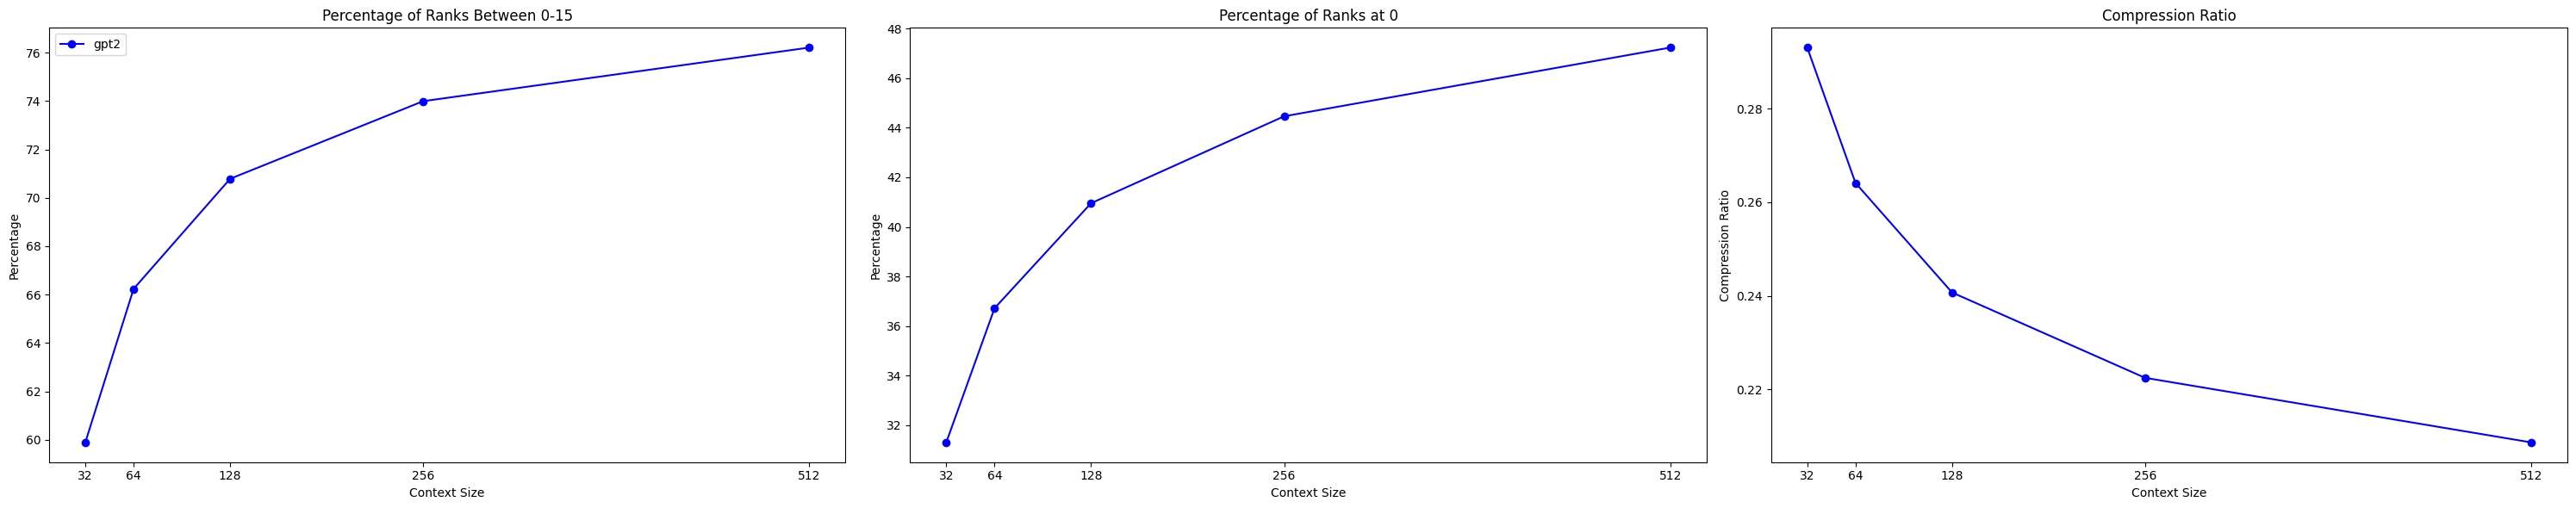

In [20]:
#Cell 2 — Chạy FineZip với 5 context size (gọi trực tiếp memory_eval() của FineZip.)
import sys
from pathlib import Path

FINEZIP_ROOT = Path("/kaggle/working/finezip")

if str(FINEZIP_ROOT) not in sys.path:
    sys.path.insert(0, str(FINEZIP_ROOT))

from finezip.eval_clean import memory_eval

FINEZIP_INPUT = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"

FINEZIP_CONTEXTS = [32, 64, 128, 256, 512]

print("========== FINEZIP EXPERIMENT ==========")
print("Input:", FINEZIP_INPUT)
print("Context sizes:", FINEZIP_CONTEXTS)
print("Model: GPT-2")
print()

memory_eval(
    finetuned_models=None,
    original_model_names=["gpt2"],
    context_sizes=FINEZIP_CONTEXTS,
    batch_size=64,
    file_path=FINEZIP_INPUT,
    save_name="finezip_context_experiment"
)


In [ ]:
#Cell 3 — Tạo thư mục output FineZip
from pathlib import Path

Path("/kaggle/working/finezip/zipped").mkdir(parents=True, exist_ok=True)
Path("/kaggle/working/finezip/plots").mkdir(parents=True, exist_ok=True)

print("FineZip output directories ready.")


**Phần B** — FineZip: lấy kết quả thành bảng
memory_eval() đã in ra compression ratio, nhưng nó chưa lưu toàn bộ compression/decompression time theo từng context theo format thuận tiện.

Lấy kích thước các .gpz sau khi chạy.

In [21]:
#Cell 4 — Đọc size FineZip
from pathlib import Path

FINEZIP_ZIPPED = Path("/kaggle/working/finezip/zipped")

finezip_results = []

for context in [32, 64, 128, 256, 512]:
    file_path = FINEZIP_ZIPPED / f"gpt2_{context}_64.gpz"

    if file_path.exists():
        compressed_size = file_path.stat().st_size
        original_size = 1_000_000

        finezip_results.append({
            "Method": "FineZip",
            "Context": context,
            "Original Size": original_size,
            "Compressed Size": compressed_size,
            "Compression Ratio": original_size / compressed_size,
            "Compressed %": compressed_size / original_size * 100
        })
    else:
        print("MISSING:", file_path)

finezip_results


[{'Method': 'FineZip',
  'Context': 32,
  'Original Size': 1000000,
  'Compressed Size': 293027,
  'Compression Ratio': 3.4126548065536624,
  'Compressed %': 29.302699999999998},
 {'Method': 'FineZip',
  'Context': 64,
  'Original Size': 1000000,
  'Compressed Size': 264110,
  'Compression Ratio': 3.786301162394457,
  'Compressed %': 26.411},
 {'Method': 'FineZip',
  'Context': 128,
  'Original Size': 1000000,
  'Compressed Size': 240733,
  'Compression Ratio': 4.153979720271006,
  'Compressed %': 24.0733},
 {'Method': 'FineZip',
  'Context': 256,
  'Original Size': 1000000,
  'Compressed Size': 222510,
  'Compression Ratio': 4.494180036852276,
  'Compressed %': 22.251},
 {'Method': 'FineZip',
  'Context': 512,
  'Original Size': 1000000,
  'Compressed Size': 208720,
  'Compression Ratio': 4.791107704101188,
  'Compressed %': 20.872}]

**Phần C **— LLMZip-Lite

In [22]:
#Cell 5 — Kiểm tra các file FineZip và lấy thời gian encode/decode
from pathlib import Path
import json

FINEZIP_ROOT = Path("/kaggle/working/finezip")

print("========== SEARCH FINEZIP METRICS ==========")

for context in [32, 64, 128, 256, 512]:
    print(f"\n--- Context {context} ---")
    
    # Tìm các file metrics/json liên quan
    matches = list(FINEZIP_ROOT.rglob(f"*{context}*"))
    
    for p in matches[:20]:
        print(p)


========== SEARCH FINEZIP METRICS ==========

--- Context 32 ---
/kaggle/working/finezip/zipped/gpt2_32_64.txt
/kaggle/working/finezip/zipped/gpt2_32_64.gpz

--- Context 64 ---
/kaggle/working/finezip/zipped/gpt2_256_64.gpz
/kaggle/working/finezip/zipped/gpt2_256_64.txt
/kaggle/working/finezip/zipped/gpt2_32_64.txt
/kaggle/working/finezip/zipped/gpt2_128_64.txt
/kaggle/working/finezip/zipped/gpt2_512_64.gpz
/kaggle/working/finezip/zipped/gpt2_128_64.gpz
/kaggle/working/finezip/zipped/gpt2_64_64.txt
/kaggle/working/finezip/zipped/gpt2_64_64.gpz
/kaggle/working/finezip/zipped/gpt2_512_64.txt
/kaggle/working/finezip/zipped/gpt2_32_64.gpz

--- Context 128 ---
/kaggle/working/finezip/zipped/gpt2_128_64.txt
/kaggle/working/finezip/zipped/gpt2_128_64.gpz

--- Context 256 ---
/kaggle/working/finezip/zipped/gpt2_256_64.gpz
/kaggle/working/finezip/zipped/gpt2_256_64.txt

--- Context 512 ---
/kaggle/working/finezip/zipped/gpt2_512_64.gpz
/kaggle/working/finezip/zipped/gpt2_512_64.txt


In [61]:
#Cell 6 — Kiểm tra memory_eval() có lưu thời gian không
import inspect
from finezip.eval_clean import memory_eval

print(inspect.getsource(memory_eval))


def memory_eval(finetuned_models=None, original_model_names=None, context_sizes=[32], batch_size=16, file_path="data/akshat.txt", save_name="eval_plots_test"):

    models = set()
    tokenizers = set()
    if finetuned_models is None and original_model_names is None:
        raise ValueError("model_dirs and original_model_names cannot both be None")
    
    if finetuned_models is None:
        finetuned_models = []
    if original_model_names is None:
        original_model_names = []
    
    for model in finetuned_models:
        models.add(model)
        tokenizers.add(finetuned_models[model])
    for model in original_model_names:
        models.add(model)
        tokenizers.add(model)

    # convert sets to lists
    models = list(models)
    tokenizers = list(tokenizers)

    print(models) 
    print(tokenizers) 

    zip_models: List[ZipModel] = []

    for i in range(len(models)):
        model = models[i]
        if model in finetuned_models:
            quant_config = BitsA

thời gian encode của FineZip đã được lưu ở dòng cuối mỗi file .txt. memory_eval() chưa lưu decode time, nên hiện tại ta lấy được encode time trước.

In [23]:
#Cell 7 — Lấy encode time + size + compression ratio của FineZip
from pathlib import Path
import os

FINEZIP_ZIPPED = Path("/kaggle/working/finezip/zipped")
ORIGINAL_SIZE = 1_000_000
CONTEXTS = [32, 64, 128, 256, 512]
BATCH_SIZE = 64

finezip_results = []

for context in CONTEXTS:
    gpz_file = FINEZIP_ZIPPED / f"gpt2_{context}_{BATCH_SIZE}.gpz"
    txt_file = FINEZIP_ZIPPED / f"gpt2_{context}_{BATCH_SIZE}.txt"

    if not gpz_file.exists():
        print("MISSING GPZ:", gpz_file)
        continue

    if not txt_file.exists():
        print("MISSING TXT:", txt_file)
        continue

    # File size
    compressed_size = gpz_file.stat().st_size

    # Last line = encode time
    with open(txt_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    encode_time = float(lines[-1])

    finezip_results.append({
        "Method": "FineZip",
        "Context": context,
        "Original Size": ORIGINAL_SIZE,
        "Compressed Size": compressed_size,
        "Compression Ratio": ORIGINAL_SIZE / compressed_size,
        "Compressed %": compressed_size / ORIGINAL_SIZE * 100,
        "Encode Time (s)": encode_time
    })

import pandas as pd

finezip_df = pd.DataFrame(finezip_results)

print("========== FINEZIP RESULTS ==========")
display(finezip_df)


========== FINEZIP RESULTS ==========


,Method,Context,Original Size,Compressed Size,Compression Ratio,Compressed %,Encode Time (s)
0,FineZip,32,1000000,293027,3.412655,29.3027,61.628860
1,FineZip,64,1000000,264110,3.786301,26.4110,67.170760
2,FineZip,128,1000000,240733,4.153980,24.0733,82.953516
3,FineZip,256,1000000,222510,4.494180,22.2510,114.332818
4,FineZip,512,1000000,208720,4.791108,20.8720,178.817302


In [63]:
#Cell 8 — kiểm tra cấu trúc code LLMZip-Lite
from pathlib import Path

ROOT = Path("/kaggle/working/finezip_experiment")

print("========== SEARCH LLMZIP-LITE FILES ==========")

for p in ROOT.rglob("*"):
    if p.is_file() and (
        "llmzip" in p.name.lower()
        or "lite" in p.name.lower()
    ):
        print(p)


========== SEARCH LLMZIP-LITE FILES ==========
/kaggle/working/finezip_experiment/llmzip_lite_1mb/llmzip_lite_results.json


In [65]:
#Cell 9 — tìm notebook
from pathlib import Path

SEARCH_ROOTS = [
    Path("/kaggle/working"),
]

print("========== SEARCH NOTEBOOKS ==========")

for root in SEARCH_ROOTS:
    for p in root.rglob("*.ipynb"):
        print(p)

========== SEARCH NOTEBOOKS ==========
/kaggle/working/.virtual_documents/__notebook_source__.ipynb


In [68]:
#Cell 10 — tìm hàm/class LLMZip-Lite đang tồn tại
print("========== SEARCH LOADED LLMZIP OBJECTS ==========")

matches = []

for name in list(globals().keys()):
    try:
        obj = globals()[name]
        name_lower = name.lower()

        if "llmzip" in name_lower or "lite" in name_lower:
            matches.append((name, type(obj), obj))
    except Exception:
        pass

if matches:
    for name, obj_type, obj in matches:
        print(f"{name:40s} | {obj_type}")
else:
    print("No LLMZip-Lite objects found in current kernel.")


========== SEARCH LOADED LLMZIP OBJECTS ==========
LLMZIP_DIR                               | <class 'pathlib.PosixPath'>


In [24]:
from pathlib import Path

SEARCH_ROOTS = [
    Path("/kaggle/working/finezip_experiment"),
    Path("/kaggle/working/finezip"),
]

keywords = [
    "LLMZIP",
    "llmzip",
    "AC_Encode",
    "ArithmeticEncoder",
    "context_size",
    "window_size",
]

print("=" * 70)
print("SEARCH PYTHON FILES FOR LLMZIP PIPELINE")
print("=" * 70)

found = set()

for root in SEARCH_ROOTS:
    if not root.exists():
        continue

    for pyfile in root.rglob("*.py"):
        try:
            text = pyfile.read_text(
                encoding="utf-8",
                errors="ignore"
            )
        except Exception:
            continue

        matched = [k for k in keywords if k in text]

        if matched:
            found.add(pyfile)
            print(f"\n{pyfile}")
            print("Matched:", matched)

print("\n" + "=" * 70)
print("TOTAL FILES:", len(found))
print("=" * 70)


SEARCH PYTHON FILES FOR LLMZIP PIPELINE

/kaggle/working/finezip/finezip/eval_clean.py
Matched: ['context_size']

/kaggle/working/finezip/AC/eval_ac.py
Matched: ['AC_Encode', 'ArithmeticEncoder', 'context_size', 'window_size']

/kaggle/working/finezip/AC/arithmeticcoding.py
Matched: ['ArithmeticEncoder']

TOTAL FILES: 3


 pipeline LLMZip-Lite chính là /kaggle/working/finezip/AC/eval_ac.py mà bạn đã gửi ở trên. Ta không cần tìm thêm.

Bây giờ chạy context = 32 trước. Cell dưới đây gọi trực tiếp eval_ac.py, dùng GPT-2 + cùng file 1 MB + batch 1, và lưu riêng kết quả.

In [25]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 32
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx32"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 32

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 32")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",

    "--model", MODEL,
    "--tokenizer", TOKENIZER,

    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),

    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,

    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(
    cmd,
    capture_output=False,
    text=True
)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

# Kiểm tra metrics
metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")
    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


LLMZIP-LITE — CONTEXT 32
Model       : gpt2
Input       : /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Output      : /kaggle/working/finezip_experiment/llmzip_lite_ctx32
Batch size  : 1
Context size: 32

Running:
python /kaggle/working/finezip/AC/eval_ac.py --model gpt2 --tokenizer gpt2 --batch_size 1 --context_size 32 --input_file /kaggle/working/finezip_experiment/data/baseline_1mb.txt --AC_output_dir /kaggle/working/finezip_experiment/llmzip_lite_ctx32 --encode_decode 1



Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1664.78it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (286273 > 1024). Running this sequence through the model will result in indexing errors
100%|██████████| 286273/286273 [48:58<00:00, 97.41it/s] 


Compression Ratio for Arithmetic Coding :  1.5012261892328334 bits/char
Reading
Successful decoded

PROCESS RETURN CODE: 0

========== METRICS ==========
{
  "$N_C$": [
    995768
  ],
  "$N_T$": [
    286273
  ],
  "$T": 2938.7180619239807,
  "AC compressed file size": [
    1494873
  ],
  "$\rho_{LLaMa+AC}$": [
    1.5012261892328334
  ],
  "Compression Ratio": [
    0.18686
  ]
}


In [26]:
#LLMZip-Lite Context 64
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 64
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx64"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 64

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 64")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


LLMZIP-LITE — CONTEXT 64
Model       : gpt2
Input       : /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Output      : /kaggle/working/finezip_experiment/llmzip_lite_ctx64
Batch size  : 1
Context size: 64

Running:
python /kaggle/working/finezip/AC/eval_ac.py --model gpt2 --tokenizer gpt2 --batch_size 1 --context_size 64 --input_file /kaggle/working/finezip_experiment/data/baseline_1mb.txt --AC_output_dir /kaggle/working/finezip_experiment/llmzip_lite_ctx64 --encode_decode 1



Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1740.83it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (286273 > 1024). Running this sequence through the model will result in indexing errors
100%|██████████| 286273/286273 [51:12<00:00, 93.16it/s]


Compression Ratio for Arithmetic Coding :  1.3552122582770283 bits/char
Reading
Successful decoded

PROCESS RETURN CODE: 0

========== METRICS ==========
{
  "$N_C$": [
    995768
  ],
  "$N_T$": [
    286273
  ],
  "$T": 3072.8099262714386,
  "AC compressed file size": [
    1349477
  ],
  "$\rho_{LLaMa+AC}$": [
    1.3552122582770283
  ],
  "Compression Ratio": [
    0.168685
  ]
}


In [27]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 128
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx128"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 128

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 128")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


LLMZIP-LITE — CONTEXT 128
Model       : gpt2
Input       : /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Output      : /kaggle/working/finezip_experiment/llmzip_lite_ctx128
Batch size  : 1
Context size: 128

Running:
python /kaggle/working/finezip/AC/eval_ac.py --model gpt2 --tokenizer gpt2 --batch_size 1 --context_size 128 --input_file /kaggle/working/finezip_experiment/data/baseline_1mb.txt --AC_output_dir /kaggle/working/finezip_experiment/llmzip_lite_ctx128 --encode_decode 1



Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1705.60it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (286273 > 1024). Running this sequence through the model will result in indexing errors
100%|██████████| 286273/286273 [58:24<00:00, 81.68it/s] 


Compression Ratio for Arithmetic Coding :  1.260180082107479 bits/char
Reading
Successful decoded

PROCESS RETURN CODE: 0

========== METRICS ==========
{
  "$N_C$": [
    995768
  ],
  "$N_T$": [
    286273
  ],
  "$T": 3504.6694238185883,
  "AC compressed file size": [
    1254847
  ],
  "$\rho_{LLaMa+AC}$": [
    1.260180082107479
  ],
  "Compression Ratio": [
    0.156856
  ]
}


In [34]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 256
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx256"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 256

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 256")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")


LLMZIP-LITE — CONTEXT 256
Model       : gpt2
Input       : /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Output      : /kaggle/working/finezip_experiment/llmzip_lite_ctx256
Batch size  : 1
Context size: 256

Running:
python /kaggle/working/finezip/AC/eval_ac.py --model gpt2 --tokenizer gpt2 --batch_size 1 --context_size 256 --input_file /kaggle/working/finezip_experiment/data/baseline_1mb.txt --AC_output_dir /kaggle/working/finezip_experiment/llmzip_lite_ctx256 --encode_decode 1



Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1640.74it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (286273 > 1024). Running this sequence through the model will result in indexing errors
100%|██████████| 286273/286273 [1:46:21<00:00, 44.86it/s]


Compression Ratio for Arithmetic Coding :  1.1691086678824787 bits/char
Reading
Successful decoded

PROCESS RETURN CODE: 0

========== METRICS ==========
{
  "$N_C$": [
    995768
  ],
  "$N_T$": [
    286273
  ],
  "$T": 6381.507926225662,
  "AC compressed file size": [
    1164161
  ],
  "$\rho_{LLaMa+AC}$": [
    1.1691086678824787
  ],
  "Compression Ratio": [
    0.145521
  ]
}


In [ ]:
import os
import json
import subprocess
from pathlib import Path

# ============================================================
# LLMZIP-LITE — CONTEXT 512
# ============================================================

INPUT_FILE = "/kaggle/working/finezip_experiment/data/baseline_1mb.txt"
OUTPUT_DIR = "/kaggle/working/finezip_experiment/llmzip_lite_ctx512"

MODEL = "gpt2"
TOKENIZER = "gpt2"

BATCH_SIZE = 1
CONTEXT_SIZE = 512

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LLMZIP-LITE — CONTEXT 512")
print("=" * 70)
print("Model       :", MODEL)
print("Input       :", INPUT_FILE)
print("Output      :", OUTPUT_DIR)
print("Batch size  :", BATCH_SIZE)
print("Context size:", CONTEXT_SIZE)
print()

cmd = [
    "python",
    "/kaggle/working/finezip/AC/eval_ac.py",
    "--model", MODEL,
    "--tokenizer", TOKENIZER,
    "--batch_size", str(BATCH_SIZE),
    "--context_size", str(CONTEXT_SIZE),
    "--input_file", INPUT_FILE,
    "--AC_output_dir", OUTPUT_DIR,
    "--encode_decode", "1",
]

print("Running:")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, text=True)

print()
print("=" * 70)
print("PROCESS RETURN CODE:", result.returncode)
print("=" * 70)

metrics_file = Path(OUTPUT_DIR) / "metrics.json"

if metrics_file.exists():
    print("\n========== METRICS ==========")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    print(json.dumps(metrics, indent=2))
else:
    print("\nWARNING: metrics.json chưa được tạo.")

LLMZIP-LITE — CONTEXT 512
Model       : gpt2
Input       : /kaggle/working/finezip_experiment/data/baseline_1mb.txt
Output      : /kaggle/working/finezip_experiment/llmzip_lite_ctx512
Batch size  : 1
Context size: 512

Running:
python /kaggle/working/finezip/AC/eval_ac.py --model gpt2 --tokenizer gpt2 --batch_size 1 --context_size 512 --input_file /kaggle/working/finezip_experiment/data/baseline_1mb.txt --AC_output_dir /kaggle/working/finezip_experiment/llmzip_lite_ctx512 --encode_decode 1



Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1666.86it/s, Materializing param=transformer.wte.weight]             
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (286273 > 1024). Running this sequence through the model will result in indexing errors
 61%|██████    | 174599/286273 [2:07:18<1:21:35, 22.81it/s]

In [1]:
from pathlib import Path

p = Path("/kaggle/working/finezip_experiment/llmzip_lite_ctx512")

print("Exists:", p.exists())
if p.exists():
    for x in p.iterdir():
        print(x.name, x.stat().st_size)


Exists: False


In [35]:
!zip -r /kaggle/working/llmzip_lite_ctx256.zip /kaggle/working/finezip_experiment/llmzip_lite_ctx256

  adding: kaggle/working/finezip_experiment/llmzip_lite_ctx256/ (stored 0%)
  adding: kaggle/working/finezip_experiment/llmzip_lite_ctx256/metrics.json (deflated 19%)
  adding: kaggle/working/finezip_experiment/llmzip_lite_ctx256/0_AC.txt (deflated 0%)
